# PIPELINE - ADB AI for Safer Roads Safer Speeds Challenge: End-to-End Notebook

This notebook reproduces, as a single continuous walkthrough, **Phase 0-4 (confirm inputs → verify external data → compute V_safe → misalignment/score/priority → verify deliverables)** described in [`PIPELINE.md`](../PIPELINE.md), calling each `src/` module directly. Its purpose is to let a reviewer clone this repository and, simply by running this notebook from top to bottom, confirm **the computation process of the analytical model itself**.

## Data handling policy (important)

The contents of the following folders are **not regenerated or overwritten** by running this notebook. Both are treated as **given input data, read via relative paths**, since generating them requires time, external APIs, or large downloads.

| Folder | Contents | Handling in this notebook |
|---|---|---|
| `data/` (`raw/`, `external/`, `processed/`, `mapillary/`) | Overture segment GeoJSON, WorldPop rasters, OSM extraction caches, Mapillary fetch results | **Read-only**. `fetch_worldpop.py` / OSM pbf extraction / `fetch_mapillary_features.py` are not run |
| `notebooks/` (`PIPELINE.ipynb`, `fetch_mapillary_features.ipynb`, `sensitivity_analysis.ipynb`) | Interactive notebooks for pipeline reproduction, Mapillary fetching, and sensitivity analysis | This notebook is the one being run; the others are referenced only |

On the other hand, the files under `outputs/` (maps, CSV, GeoJSON/GPKG, PNG) **are actually regenerated and overwritten by this notebook**. This is to guarantee that "the deliverables the reviewer is looking at are exactly the computation results of this notebook": the `src/` modules (`schema.py` through `priority_map.py`, etc.) are **actually called within this notebook**, taking only the given data above as input, **live-recompute** V_safe, misalignment, the Speed Safety Score, and the priority class, and then write out every file under `outputs/` on the spot. At the end of Phase 2-3, this notebook also verifies that the recomputed result matches `data/processed/segments_v_safe.parquet` (given, already committed, not overwritten by this notebook) exactly. This lets the reviewer confirm, on their own, not just "looking at the deliverables" but that "the analytical model actually runs as described, and the deliverables being viewed are exactly its output."

**Approximate runtime:** since all external rasters and OSM caches already exist under `data/`, no network access occurs. Including writing out every deliverable under `outputs/`, this completes in roughly **about one minute** on a typical laptop.

In [1]:
import os
import sys
import warnings

# If run from notebooks/, move to the repo root so every path from here on is
# unified as "repo-root relative", matching PIPELINE.md / README.md.
if os.path.basename(os.getcwd) == "notebooks":
 os.chdir("..")
sys.path.insert(0, "src")
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print("working directory:", os.getcwd)

working directory: /Users/kentaroiio/Documents/github/adb-ai-for-safer-roads-safer-speeds-challenge-dev


---
# Phase 0 - Confirming inputs and the analysis population

**Goal:** align Thailand and Maharashtra's road segments to a common schema, and restrict the analysis population to segments where speed data is usable ([`PIPELINE.md` Phase 0](../PIPELINE.md#phase-0--confirming-inputs-and-the-analysis-population), `src/schema.py`).

- The authoritative data source is GeoJSON (which carries full LineString geometry). CSV is attributes-only with no geometry, so it is not used.
- Only rows with `AnalysisStatus=='Valid'` and a `SpeedLimit` present are targeted.
- Segments where `speed_limit`, `median_speed`, and `f85_speed` are all 0 (410 in Thailand) keep their row but are tagged `data_quality_flag='invalid_speed'` and quarantined from the downstream misalignment/score computation (quarantined, not excluded).

In [2]:
from schema import load_target

target = load_target
print(f"analysis population: {len(target)} segments")
print(target["country"].value_counts)
print
print("data_quality_flag (invalid_speed = speed_limit/median_speed/f85_speed all 0):")
print(target["data_quality_flag"].value_counts(dropna=False))

analysis population: 15121 segments
country
thailand 11544
maharashtra 3577
Name: count, dtype: int64

data_quality_flag (invalid_speed = speed_limit/median_speed/f85_speed all 0):
data_quality_flag
<NA> 14711
invalid_speed 410
Name: count, dtype: int64


In [3]:
target.head(3)[
 ["segment_id", "country", "road_class", "land_use", "speed_limit", "median_speed", "f85_speed",
 "sample_size_total", "analysis_status", "data_quality_flag"]
]


,segment_id,country,road_class,land_use,speed_limit,median_speed,f85_speed,sample_size_total,analysis_status,data_quality_flag
1,2,thailand,primary,RURAL,66.0,78.380000,115.200000,222398.0,Valid,<NA>
5,6,thailand,primary,URBAN,70.0,56.766667,84.666667,83189.0,Valid,<NA>
6,7,thailand,primary,RURAL,30.0,15.450000,21.000000,10.0,Valid,<NA>


---
# Phase 1 - Verifying external data and coverage (checking the given data)

**Goal:** confirm that the auxiliary data used as input to V_safe (VRU exposure, separation structure) is already in place, and that its coverage has been verified on the ground ([`PIPELINE.md` Phase 1](../PIPELINE.md#phase-1--verifying-external-data-and-coverage)).

**Nothing is fetched or re-extracted here.** Downloading the full WorldPop rasters (`fetch_worldpop.py`), extracting POIs/crossings/road network from the OSM pbf (the `extract_*`/`cache_*` functions in `exposure_signals.py` / `road_separation.py`), and bulk-fetching from the Mapillary `/map_features` API (`fetch_mapillary_features.py`) all take minutes to tens of minutes and require an API token; they are already cached under `data/external/`, `data/processed/`, and `data/mapillary/`. The cells below only confirm that **those given files exist and contain the expected volume**.

In [4]:
external_files = [
 "data/external/tha_ppp_2020.tif",
 "data/external/maharashtra_ppp_2020.tif",
 "data/external/thailand-260621.osm.pbf",
 "data/external/western-zone-260621.osm.pbf",
 "data/external/osm_junctions_thailand.geojson",
 "data/external/osm_junctions_maharashtra.geojson",
]
for path in external_files:
 size_mb = os.path.getsize(path) / 1e6
 print(f"{'OK' if os.path.exists(path) else 'MISSING':7s} {path} ({size_mb:,.1f} MB)")


OK data/external/tha_ppp_2020.tif (296.0 MB)
OK data/external/maharashtra_ppp_2020.tif (305.6 MB)
OK data/external/thailand-260621.osm.pbf (323.7 MB)
OK data/external/western-zone-260621.osm.pbf (215.0 MB)
OK data/external/osm_junctions_thailand.geojson (2.4 MB)
OK data/external/osm_junctions_maharashtra.geojson (1.2 MB)


`osm_junctions_{country}.geojson` was obtained through a different path than the other external data (WorldPop / OSM pbf): rather than parsing `.osm.pbf` with pyrosm, it's an export that directly extracted `highway=traffic_signals` / `junction=yes` via Overpass Turbo. Once V_safe is finalized in Phase 2, it's used as the input to the junction-buffer 50km/h cap (`junction_speed_cap.py`).

In [5]:
import geopandas as gpd

processed_caches = {
 "OSM POI (thailand)": "data/processed/osm_pois_thailand.parquet",
 "OSM POI (maharashtra)": "data/processed/osm_pois_maharashtra.parquet",
 "OSM pedestrian ways (thailand)": "data/processed/osm_pedestrian_ways_thailand.parquet",
 "OSM pedestrian ways (maharashtra)": "data/processed/osm_pedestrian_ways_maharashtra.parquet",
 "OSM at-grade crossings (thailand)": "data/processed/osm_crossings_at_grade_thailand.parquet",
 "OSM at-grade crossings (maharashtra)": "data/processed/osm_crossings_at_grade_maharashtra.parquet",
 "OSM road network (thailand)": "data/processed/osm_roads_thailand.parquet",
 "OSM road network (maharashtra)": "data/processed/osm_roads_maharashtra.parquet",
 "Mapillary POI (thailand)": "data/processed/mapillary_pois_thailand.parquet",
 "Mapillary POI (maharashtra)": "data/processed/mapillary_pois_maharashtra.parquet",
}
for label, path in processed_caches.items:
 n = len(gpd.read_parquet(path)) if os.path.exists(path) else None
 print(f"{label:32s} {path:55s} n={n}")

OSM POI (thailand) data/processed/osm_pois_thailand.parquet n=71041
OSM POI (maharashtra) data/processed/osm_pois_maharashtra.parquet n=26306
OSM pedestrian ways (thailand) data/processed/osm_pedestrian_ways_thailand.parquet n=44798
OSM pedestrian ways (maharashtra) data/processed/osm_pedestrian_ways_maharashtra.parquet n=6641
OSM at-grade crossings (thailand) data/processed/osm_crossings_at_grade_thailand.parquet n=22604
OSM at-grade crossings (maharashtra) data/processed/osm_crossings_at_grade_maharashtra.parquet n=1603
OSM road network (thailand) data/processed/osm_roads_thailand.parquet n=25936
OSM road network (maharashtra) data/processed/osm_roads_maharashtra.parquet n=17504
Mapillary POI (thailand) data/processed/mapillary_pois_thailand.parquet n=168953
Mapillary POI (maharashtra) data/processed/mapillary_pois_maharashtra.parquet n=3026


In [6]:
from pathlib import Path
import pandas as pd

# school_isochrones parquet (Valhalla pedestrian isochrone cache)
# If the parquet exists, add_poi_proximity determines the school VRU zone via the isochrone (default).
# If it doesn't exist, falls back automatically to a dwithin circular buffer (urban 200m / rural 400m).
for country in ["thailand", "maharashtra"]:
 p = Path(f"data/processed/school_isochrones_{country}.parquet")
 if p.exists:
 iso = pd.read_parquet(p, columns=["source", "land_use"])
 src = iso["source"].value_counts.to_dict
 print(f"school_isochrones_{country}.parquet: {len(iso)} rows source={src}")
 else:
 print(f"school_isochrones_{country}.parquet: not found -> dwithin fallback")

school_isochrones_thailand.parquet: 17142 rows source={'isochrone': 17142}
school_isochrones_maharashtra.parquet: 2287 rows source={'isochrone': 2287}


In [7]:
import json

mapillary_json = {
 "thailand": "data/mapillary/map_features_thailand.json",
 "maharashtra": "data/mapillary/map_features_maharashtra.json",
}
for country, path in mapillary_json.items:
 with open(path) as f:
 by_objectid = json.load(f)
 n_segments_with_features = len(by_objectid)
 n_features = sum(len(v) for v in by_objectid.values)
 size_mb = os.path.getsize(path) / 1e6
 print(f"{country:12s} {path} ({size_mb:,.1f} MB) -- "
 f"{n_features} map_features linked to {n_segments_with_features} segments")

thailand data/mapillary/map_features_thailand.json (52.4 MB) -- 168953 map_features linked to 55884 segments
maharashtra data/mapillary/map_features_maharashtra.json (1.2 MB) -- 3026 map_features linked to 14082 segments


**What was verified on the ground (already done via the modules below; not individually re-run here):**

- `src/safe_system_inputs.py` - inventory of Safe System arguments (speed is not yet decided)
- `src/osm_coverage.py` / `src/mapillary_coverage.py` - on-the-ground coverage check of OSM pedestrian tags / Mapillary imagery
- `src/auxiliary_data.py` - URL / license inventory for WorldPop / OSM / Mapillary

The cell below reproduces that verification (representative-point plot, F85 diagnostics) by calling `src/safe_system_inputs.py` / `src/plot_representative_points.py`. The diagnostic plots themselves are lightweight (only the given GeoJSON as input), so they are actually called here, regenerating the corresponding PNG under `outputs/`.

saved outputs/representative_points.png
saved outputs/f85_by_category.png
saved outputs/speedlimit_vs_f85_diagnostic.png


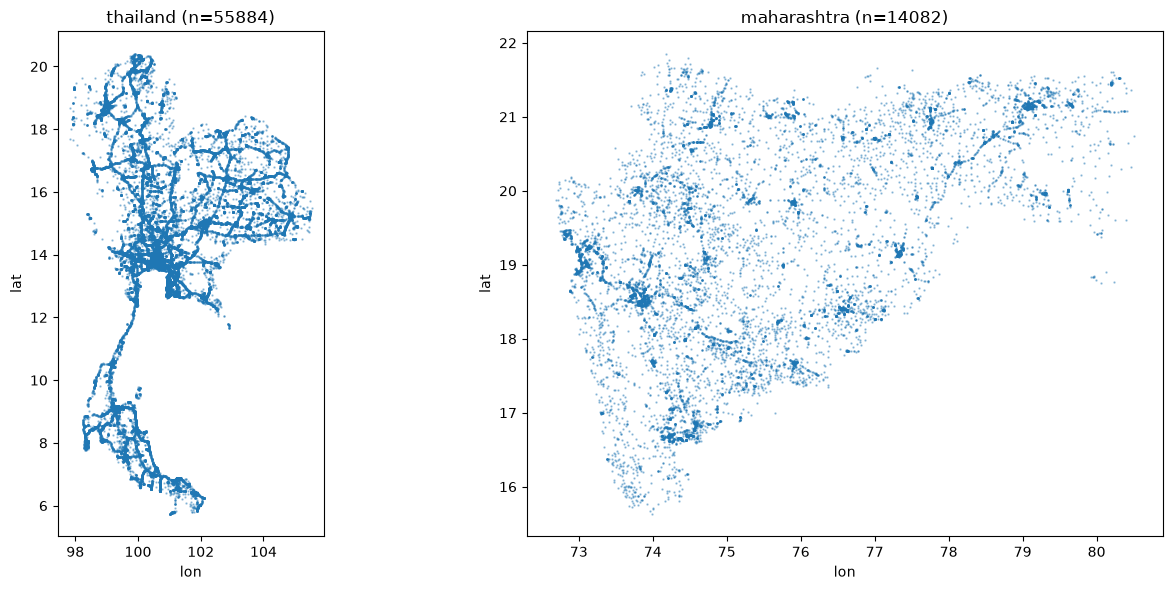

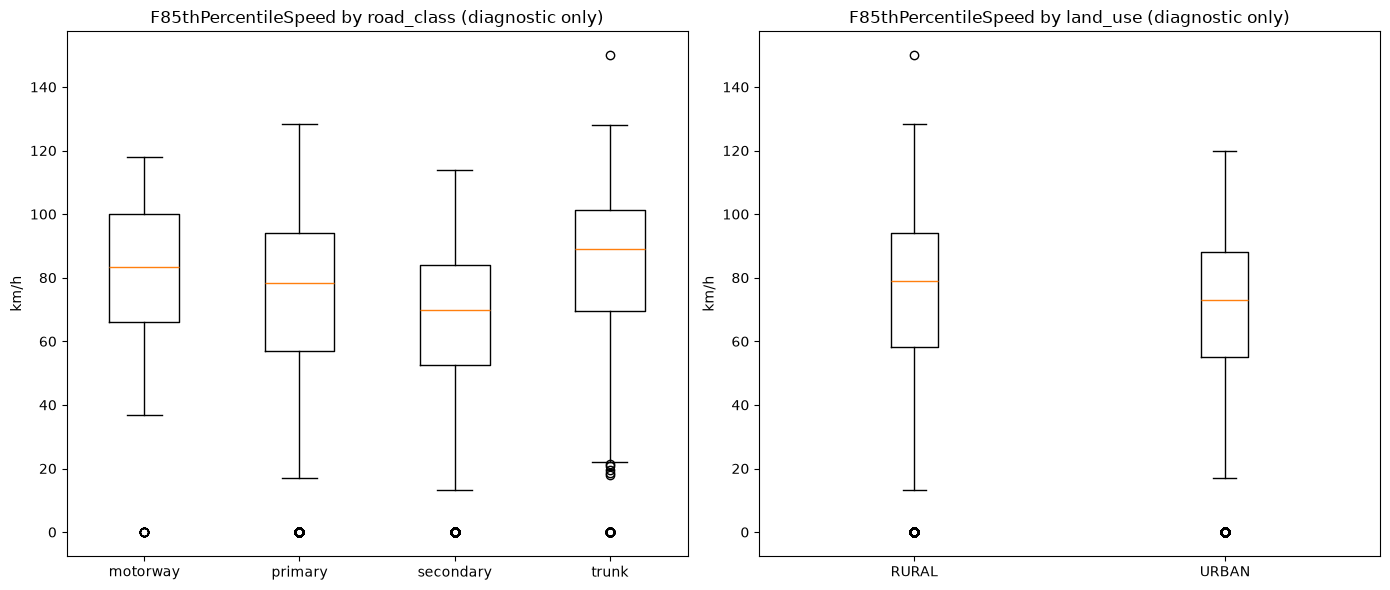

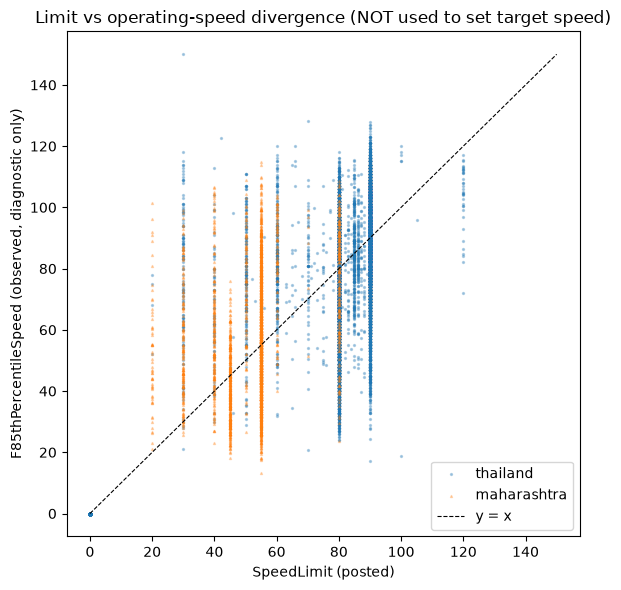

In [8]:
from geometry import add_representative_point
from plot_representative_points import plot as plot_representative_points
from schema import load_combined, valid_only
from safe_system_inputs import boxplot_f85_by_category, speed_limit_vs_f85_scatter

combined_all = load_combined
combined_valid = valid_only(combined_all)

plot_representative_points(add_representative_point(combined_all))
boxplot_f85_by_category(combined_valid)
speed_limit_vs_f85_scatter(combined_valid)


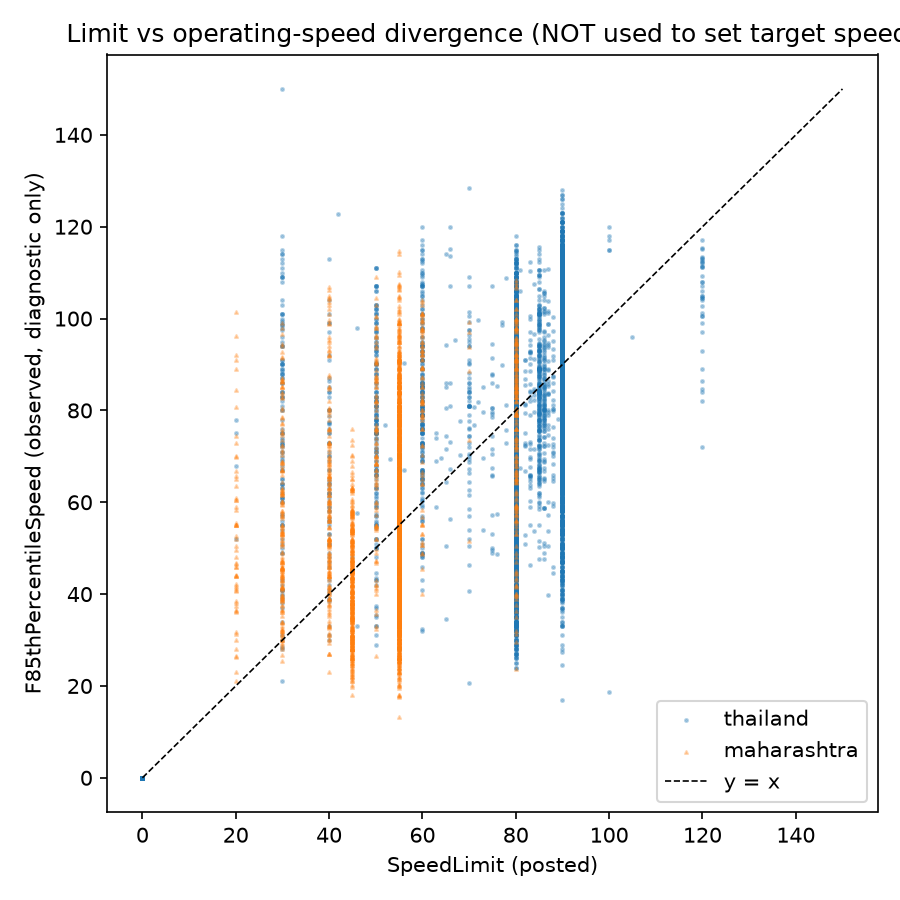

In [9]:
display(Image("outputs/speedlimit_vs_f85_diagnostic.png"))


**Conclusion of the coverage check (pipeline branch point):**

- Urban: OSM crossing structure + Mapillary are usable -> exposure track A
- Rural: OSM/Mapillary coverage is thin -> population + POIs as the primary axis + **safety-side correction**

This branch is reflected directly in Phase 2's `exposure_level.py` (which discretizes `URBAN_SIGNALS` / `RURAL_SIGNALS` on separate tracks).

---
# Phase 2 - V_safe and VRU exposure (live recompute)

**Goal:** without using `SpeedLimit` or observed speed, determine per segment "the speed at which someone can be hit on this road and survive" ([`PIPELINE.md` Phase 2](../PIPELINE.md#phase-2--v_safe-and-vru-exposure)).

**Design principle (a constraint that must not be broken):** `safe_speed.classify_collision_type` / `compute_v_safe` take neither `speed_limit` nor observed speed as arguments. V_safe is structured so that it is never influenced by the posted speed limit.

Below, each `src/` module is called using only the given caches verified in Phase 1 as input. No network access or OSM pbf re-parsing occurs.

## Determining road separation structure (`road_separation.py`) - run before the other modules

Spatially matches the OSM road network (motorway/trunk/primary/secondary) to segments using a 15m buffer, setting `is_separated=True` only when **every matched way satisfies** conditions such as `(highway in {motorway,trunk} and oneway=='yes')`. If no corresponding OSM way was found, `is_separated_confidence='low'` (distinguishing "confirmed as not separated" from "no basis for judgment").

Run before `add_poi_proximity` since it doesn't depend on `pop_density` or POI-related columns. `is_separated` is used as a masking condition for `is_vru`/`is_mapillary_vru` in the next cell.

In [10]:
from road_separation import add_is_separated

target = add_is_separated(target)
print(target.groupby(["country", "road_class"])["is_separated"].sum)
print
print("is_separated_confidence:")
print(target["is_separated_confidence"].value_counts)


country road_class
maharashtra motorway 18
 primary 12
 secondary 11
 trunk 290
thailand motorway 52
 primary 67
 secondary 43
 trunk 800
Name: is_separated, dtype: int64

is_separated_confidence:
is_separated_confidence
high 7926
low 7195
Name: count, dtype: int64


In [11]:
from pop_density import add_pop_density

target = add_pop_density(target)
print(target.groupby("country")["pop_density"].describe[["count", "mean", "50%", "max"]])


 count mean 50% max
country 
maharashtra 3577.0 34.048557 18.260500 582.25885
thailand 11544.0 20.594853 8.136042 280.82550


## POI proximity and crossing structure (`exposure_signals.py`)

Spatially joins segments to OSM/Mapillary-derived POI points, after UTM projection, using `dwithin` (urban 200m / rural 400m). No per-segment buffer polygon is built (the old implementation took ~55 minutes for all of Thailand; the `dwithin` approach takes ~3 seconds). Crossing structure is matched only for urban segments, at 25m ([`PIPELINE.md` Phase 2 table](../PIPELINE.md#phase-2--v_safe-and-vru-exposure)).

`is_vru` (the source-agnostic VRU trigger that drives V_safe) is true (0/1) if `is_mapillary_vru` (the OR of Mapillary-detected school-zone signs / crosswalk markings / bicycle markings) **or** an OSM school node (`amenity=school`) is nearby. Because a school rarely grade-separates from a non-access-controlled road, and Mapillary coverage is incomplete, OSM schools are also treated as at-grade VRU evidence. Both `is_vru` and `is_mapillary_vru` are **forced to False** for motorway/trunk segments and for segments with `is_separated==True` (since a nearby detection doesn't mean a pedestrian-vehicle collision happens "on this segment"). Schools also remain on the exposure side (`osm_poi_category_count`), so they affect both axes (double counting is allowed, the same policy as for Mapillary VRU).

In [12]:
# School VRU zone definition:
# Default (use_isochrone=True): uses data/processed/school_isochrones_*.parquet.
# If the parquet exists, is_school is determined via the Valhalla pedestrian isochrone
# (urban 3 min / rural 5 min).
# Rural: isochrone union 200m circular floor (safety-side supplement for areas where
# the OSM pedestrian network is sparse).
# If the parquet doesn't exist, falls back automatically to dwithin (urban 200m / rural 400m).
# To switch to the circular buffer: add_poi_proximity(target, use_isochrone=False)
from exposure_signals import add_crossing_signal, add_poi_proximity

target = add_poi_proximity(target) # use_isochrone=True is the default
# target = add_poi_proximity(target, use_isochrone=False) # to use the circular buffer
target = add_crossing_signal(target)

print("poi_count distribution (by land_use):")
print(target.groupby("land_use")["poi_count"].describe[["count", "mean", "50%", "max"]])
print
print("has_crossing (a signal meaningful for urban segments only):")
print(target.groupby("land_use")["has_crossing"].mean)
print
print("is_mapillary_vru (Mapillary-only, urban exposure signal):", int(target["is_mapillary_vru"].sum), "/", len(target))
print("is_vru (V_safe trigger = Mapillary VRU or OSM school):", int(target["is_vru"].sum),
 "/", len(target), "(of which from OSM school:", int((target["is_vru"] & ~target["is_mapillary_vru"]).sum), ")")
masked_violation = target["is_vru"] & (target["road_class"].isin(["motorway", "trunk"]) | target["is_separated"])
print("masking leaks (motorway/trunk or is_separated==True but is_vru True):", int(masked_violation.sum), "(should be 0)")

poi_count distribution (by land_use):
 count mean 50% max
land_use 
RURAL 8599.0 10.254681 1.0 1229.0
URBAN 6522.0 45.428243 5.0 2393.0

has_crossing (a signal meaningful for urban segments only):
land_use
RURAL 0.025584
URBAN 0.139374
Name: has_crossing, dtype: float64

is_mapillary_vru (Mapillary-only, urban exposure signal): 2211 / 15121
is_vru (V_safe trigger = Mapillary VRU or OSM school): 5303 / 15121 (of which from OSM school: 3092)
masking leaks (motorway/trunk or is_separated==True but is_vru True): 0 (should be 0)


## Discretizing exposure level and the rural safety-side correction (`exposure_level.py`) - for prioritization only

Urban and rural are discretized on **separate tracks** (different signal sets and different quantiles; urban also includes `is_mapillary_vru`). For rural segments where "population is high but no crossing structure is detected," `exposure_level` is raised to at least `medium` and tagged `exposure_confidence='low'` (the implementation of design principle 5, "absence of data does not mean absence of exposure"). Thresholds are computed per country.

**`exposure_level` is not used to determine V_safe.** It is a signal used **only for prioritizing** intervention sites, via the exposure axis (weight 35%) in `safety_score.py` and the ranking in `priority_lists.py`. V_safe's collision-type classification is determined directly from `is_vru`/`is_separated` in the next cell (`is_mapillary_vru` is used here only as the URBAN sub-signal of exposure).

In [13]:
from exposure_level import add_exposure_level, apply_rural_safety_margin

target = add_exposure_level(target)
target, rural_thresholds = apply_rural_safety_margin(target)

print("rural safety-side correction thresholds (per-country pop_density 75th percentile):")
print(rural_thresholds)
print
print(target.groupby(["country", "land_use"])["exposure_level"].value_counts.unstack)
print
print("exposure_confidence (by land_use; 'low' should only appear for rural):")
print(target.groupby("land_use")["exposure_confidence"].value_counts)

rural safety-side correction thresholds (per-country pop_density 75th percentile):
{'thailand': np.float64(8.468535423278809), 'maharashtra': np.float64(22.866260528564453)}

exposure_level low medium high
country land_use 
maharashtra RURAL 939 938 939
 URBAN 254 253 254
thailand RURAL 1797 2058 1928
 URBAN 1921 1921 1919

exposure_confidence (by land_use; 'low' should only appear for rural):
land_use exposure_confidence
RURAL high 6553
 low 2046
URBAN high 6522
Name: count, dtype: int64


## Finalizing V_safe (`safe_speed.py`)

The collision type (pedestrian/separated/head_on) is classified directly from `is_vru` (VRU detection = Mapillary VRU sign/marking or an OSM school node) and `is_separated` (physical separation), and V_safe is set from a fixed WHO/iRAP-style threshold table. Motorways carry a physical exception as access-controlled, but this exception is lifted if `F85` is abnormally low (`motorway_tag_suspect`). `side_impact` (50km/h) is not assigned at this point -- it's used only in the junction-buffer cell next.

In [14]:
from safe_speed import add_v_safe

target = add_v_safe(target)

print("V_safe (road_class x land_use, median, before junction cap):")
print(target.groupby(["road_class", "land_use"])["v_safe"].median.unstack)
print
print("collision_type distribution (before junction cap; side_impact should still be 0):")
print(target["collision_type"].value_counts)
print
print("count of collision_type=='pedestrian' should match count of is_vru==True:",
 int((target["collision_type"] == "pedestrian").sum), "vs", int(target["is_vru"].sum))

V_safe (road_class x land_use, median, before junction cap):
land_use RURAL URBAN
road_class 
motorway 100.0 70.0
primary 70.0 70.0
secondary 70.0 70.0
trunk 70.0 70.0

collision_type distribution (before junction cap; side_impact should still be 0):
collision_type
head_on 8525
pedestrian 5303
separated 1293
Name: count, dtype: int64

count of collision_type=='pedestrian' should match count of is_vru==True: 5303 vs 5303


## The 50km/h junction-buffer cap (`junction_speed_cap.py`)

Under Safe System, the survivable speed at a junction (side-impact risk) is taken to be roughly 50km/h. Using a 300m dwithin join against OSM `highway=traffic_signals` / `junction=yes` nodes (Overpass Turbo extract, `data/external/osm_junctions_*.geojson`), V_safe for the corresponding segments is capped to `min(v_safe, 50)`. **This is applied even for `is_separated` segments and motorways** (a signalized junction is itself the point where separation breaks down, even on an otherwise separated road). Via the second-stage refinement (P1-0), long segments within a junction buffer are split into an affected portion and an unaffected portion, localizing V_safe (see the cell below).

In [15]:
from junction_speed_cap import JUNCTION_V_SAFE_CAP, add_junction_speed_cap

target = add_junction_speed_cap(target)

capped = target["v_safe_basis"] == "side_impact:junction_buffer"
print(f"within junction buffer: {int(target['near_junction'].sum)} / {len(target)}")
print(f"segments capped to {JUNCTION_V_SAFE_CAP}km/h (pre-cap value > {JUNCTION_V_SAFE_CAP}): "
 f"{int(capped.sum)} / {len(target)} ({capped.mean:.1%})")
print(f"within junction buffer but already <= {JUNCTION_V_SAFE_CAP} (unchanged): {int((target['near_junction'] & ~capped).sum)}")
print
print("V_safe (road_class x land_use, median, after junction cap):")
print(target.groupby(["road_class", "land_use"])["v_safe"].median.unstack)
print
urban_median = target.loc[target["land_use"] == "URBAN", "v_safe"].median
rural_median = target.loc[target["land_use"] == "RURAL", "v_safe"].median
print(f"urban median V_safe={urban_median}, rural median V_safe={rural_median} "
 f"({'OK: urban <= rural' if urban_median <= rural_median else 'CHECK: urban > rural'})")

within junction buffer: 3979 / 15121
segments capped to 50km/h (pre-cap value > 50): 2079 / 15121 (13.7%)
within junction buffer but already <= 50 (unchanged): 1900

V_safe (road_class x land_use, median, after junction cap):
land_use RURAL URBAN
road_class 
motorway 100.0 60.0
primary 70.0 50.0
secondary 50.0 50.0
trunk 70.0 70.0

urban median V_safe=50.0, rural median V_safe=70.0 (OK: urban <= rural)


## Second stage: localization via influence-zone clipping (`segment_localization.py`, P1-0)

The first stage (cells above) applied the `is_vru` / `near_junction` flags to the **entire segment**.
For long segments, this lowers V_safe across the whole segment even when the POI/junction only
affects part of it.

**Second stage (P1-0):** for flagged segments, clips the segment using an influence-zone polygon
built from the influence radius, splitting it into an "affected portion" and an "unaffected portion".
The affected portion gets the lower V_safe; the unaffected portion keeps the original V_safe.

- Influence radius: Mapillary VRU / OSM school = urban 200m / rural 400m, junction = 300m
- Speed-up: buffer only the points near the target segment using a `dwithin` pre-filter (no
 country-wide bulk union)
- Safety-side sliver absorption: short unaffected gaps (< 50m) between influence zones are
 absorbed into the affected side (Safe System precautionary principle)
- `sample_size_total` is allocated to child segments length-proportionally (preserving the total
 `delta_fatal_abs`)
- `segment_id` is normalised to the `{country}_{objectid}` form (preventing OBJECTID collisions
 between Thailand and Maharashtra)
- After splitting, the same geometry-driven functions are re-run to finalize V_safe for each child
 segment

In [16]:
import time
from segment_localization import refine_influenced_segments
from road_separation import add_is_separated
from pop_density import add_pop_density
from exposure_signals import add_poi_proximity, add_crossing_signal
from exposure_level import add_exposure_level, apply_rural_safety_margin
from safe_speed import add_v_safe
from junction_speed_cap import add_junction_speed_cap

n_before = len(target)
t0 = time.time
target = refine_influenced_segments(target)
n_children = int(target["parent_section_id"].notna.sum)
n_split_parents = int(target.loc[target["parent_section_id"].notna, "parent_section_id"].nunique)
print(f"before split: {n_before} segments -> after split: {len(target)} segments (+{len(target) - n_before} rows)")
print(f"split parent segments: {n_split_parents} segments -> expanded into {n_children} child segments")

# Recompute the V_safe-related columns on the post-split geometry
# (unsplit rows have unchanged geometry, so they yield the same values)
target = add_is_separated(target)
target = add_pop_density(target)
target = add_poi_proximity(target)
target = add_crossing_signal(target)
target = add_exposure_level(target)
target, rural_thresholds = apply_rural_safety_margin(target)
target = add_v_safe(target)
target = add_junction_speed_cap(target)
print(f"geometry-driven column recompute complete ({time.time-t0:.0f}s)")
print
print("V_safe (road_class x land_use median, after refinement):")
print(target.groupby(["road_class", "land_use"])["v_safe"].median.unstack)
print
urban_med = target.loc[target["land_use"] == "URBAN", "v_safe"].median
rural_med = target.loc[target["land_use"] == "RURAL", "v_safe"].median
print(f"urban median V_safe={urban_med}, rural median V_safe={rural_med} "
 f"({'OK: urban <= rural' if urban_med <= rural_med else 'CHECK: urban > rural'})")

[segment_localization] split 6427 segments into 31344 children (net +24917 rows)
before split: 15121 segments -> after split: 40038 segments (+24917 rows)
split parent segments: 6427 segments -> expanded into 31344 child segments
geometry-driven column recompute complete (143s)

V_safe (road_class x land_use median, after refinement):
land_use RURAL URBAN
road_class 
motorway 100.0 70.0
primary 30.0 30.0
secondary 30.0 30.0
trunk 70.0 70.0

urban median V_safe=50.0, rural median V_safe=30.0 (CHECK: urban > rural)


saved outputs/v_safe_map.png


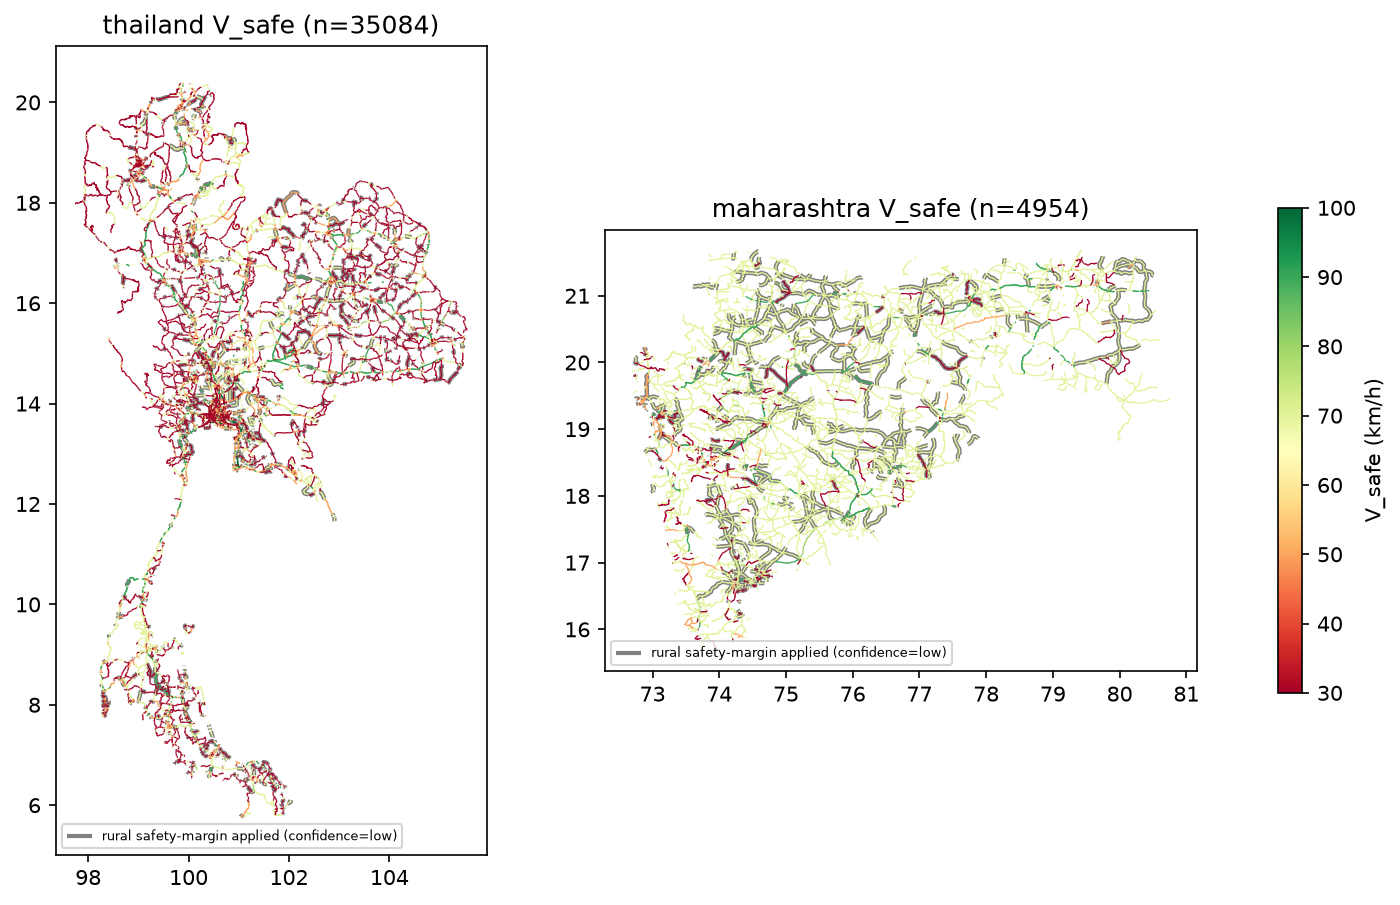

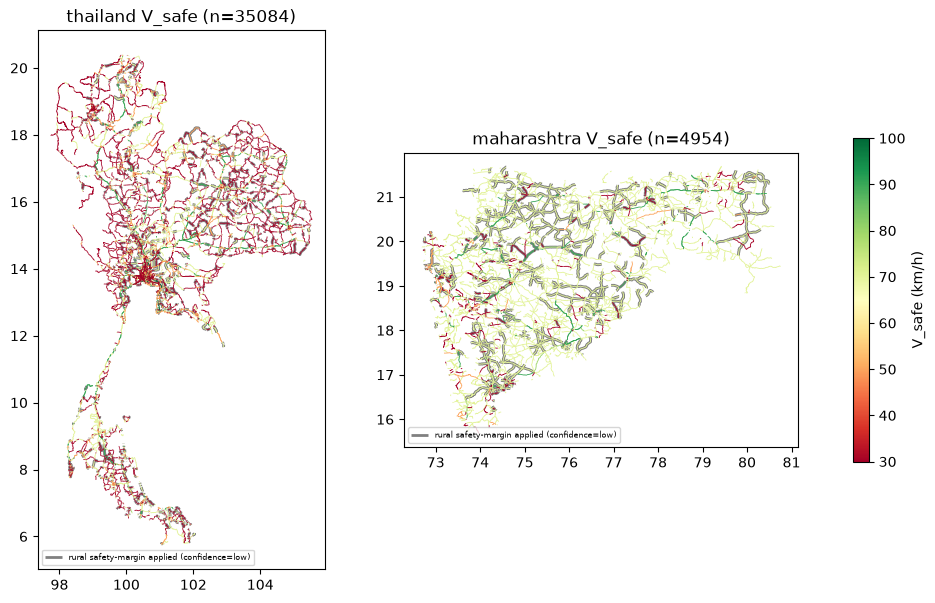

In [17]:
from build_v_safe import plot_map

# Regenerate outputs/v_safe_map.png with the same function used by build_v_safe.py itself (V_safe after the junction cap).
plot_map(target)
display(Image("outputs/v_safe_map.png"))

---
# Phase 3 - Misalignment, Speed Safety Score, and priority list (live recompute)

**Goal:** score "segments where the posted speed limit is too high" and turn that into a list and map the ministry of transport can use ([`PIPELINE.md` Phase 3](../PIPELINE.md#phase-3--misalignment-speed-safety-score-and-priority-list)).

## SpeedLimit plausibility (`speedlimit_plausibility.py`)

`SpeedLimit` is not treated as ground truth; confidence is assessed purely from internal data consistency: (1) IQR outliers within the same (country, road_class, land_use) peer group, (2) extreme divergence of `|F85 - SpeedLimit| > 30km/h`. Segments with `data_quality_flag` set are excluded from the peer group's IQR computation and are not themselves assigned a plausibility verdict.

In [18]:
from speedlimit_plausibility import add_speedlimit_plausibility

target = add_speedlimit_plausibility(target)
print(target["speedlimit_plausibility"].value_counts(dropna=False))


speedlimit_plausibility
high 34701
low 4636
NaN 701
Name: count, dtype: int64


## Misalignment (`misalignment.py`)

**`misalignment = speed_limit - v_safe`** is the primary axis of this project. `operating_gap = f85_speed - v_safe` is diagnostic-only and is not folded into the score. Segments with `data_quality_flag` set are NA on both axes.

In [19]:
from misalignment import add_misalignment

target = add_misalignment(target)
usable = target[target["data_quality_flag"].isna]
too_high = usable["misalignment"] > 0
print(f"misalignment in the \"too high\" direction (review priority): {too_high.sum} / {len(usable)} ({too_high.mean:.1%})")
print
print(usable.groupby("road_class")["misalignment"].agg(["count", "mean"]))

misalignment in the "too high" direction (review priority): 33475 / 39337 (85.1%)

 count mean
road_class 
motorway 874 16.183066
primary 11053 35.405048
secondary 18954 39.830379
trunk 8456 11.971973


## Fatality-reduction estimate (`fatality_reduction.py`, Power Model)

`delta_fatal_percent = (1 - (V_safe / median_speed) ** p) * 100`. The exponent `p` uses the per-road-environment category (`fatal_accidents`) from Cameron & Elvik (2010) / Elvik (2009), and its 95% confidence interval is propagated alongside it (not just a single point estimate).

In [20]:
from fatality_reduction import add_fatal_reduction

target = add_fatal_reduction(target)
usable = target[target["data_quality_flag"].isna]
print(usable.groupby("power_environment_used")[
 ["power_exponent_used", "power_exponent_ci_low", "power_exponent_ci_high", "delta_fatal_percent"]
].agg({"power_exponent_used": "first", "power_exponent_ci_low": "first",
 "power_exponent_ci_high": "first", "delta_fatal_percent": "mean"}))


 power_exponent_used power_exponent_ci_low power_exponent_ci_high delta_fatal_percent
power_environment_used 
rural_freeway 4.1 2.9 5.3 -304.190859
urban_residential 2.6 0.3 4.9 -51.749549


## Speed Safety Score (`safety_score.py`)

```
safety_score = 100 x (0.50 x misalignment + 0.35 x exposure + 0.15 x confidence)
```

The boundaries of the priority class (Top Priority/Priority/Watch/No Issue) are set by percentile **per country** (Thailand's and Maharashtra's score distributions are not pooled).

In [21]:
from safety_score import add_safety_score

target, score_thresholds = add_safety_score(target)
print("priority-class boundary scores (per country):")
for country, th in score_thresholds.items:
 print(f" {country}: {{{', '.join(f'{k}: {round(v, 1)}' for k, v in th.items)}}}")
print
usable = target[target["data_quality_flag"].isna]
print(usable.groupby("country")["priority_class"].value_counts.unstack)

priority-class boundary scores (per country):
 ('thailand', 'URBAN'): {Top Priority: 91.7, Priority: 91.7, Watch: 86.7}
 ('thailand', 'RURAL'): {Top Priority: 95.0, Priority: 90.0, Watch: 81.7}
 ('maharashtra', 'RURAL'): {Top Priority: 65.8, Priority: 53.3, Watch: 48.3}
 ('maharashtra', 'URBAN'): {Top Priority: 65.8, Priority: 57.5, Watch: 50.0}

priority_class Top Priority Priority Watch No Issue Data Quality Issue (Excluded)
country 
maharashtra 254 321 563 3816 0
thailand 2876 1058 3316 27133 0


## Triage (`review_track.py`) and per-track ranking (`priority_lists.py`)

Segments that made the priority list are split, via `speedlimit_plausibility`, into two tracks: "Review Needed" (the record is trustworthy -> review the policy) and "Field Verification Needed" (the record itself is suspect -> field verification comes first). Given that urban and rural exposure tracks differ (the Phase 2 design), the ranking is likewise split into separate lists by `urban_residential` / `rural_freeway`.

In [22]:
from review_track import FIELD_CHECK_NEEDED, REVIEW_NEEDED, add_review_track
from priority_lists import add_priority_environment_rank

target = add_review_track(target)
target = add_priority_environment_rank(target)

usable = target[target["data_quality_flag"].isna]
review = usable[usable["review_track"] == REVIEW_NEEDED]
field_check = usable[usable["review_track"] == FIELD_CHECK_NEEDED]
print(f"Review Needed: {len(review)} / Field Verification Needed: {len(field_check)} "
 f"(ratio {len(review) / max(1, len(field_check)):.1f} : 1)")
print
on_list = usable["rank_within_environment"].notna
print(usable[on_list].groupby("power_environment_used").size)

Review Needed: 7754 / Field Verification Needed: 634 (ratio 12.2 : 1)

power_environment_used
rural_freeway 4708
urban_residential 3680
dtype: int64


---
# Reproducibility check - live computation vs. the committed intermediate artifact

Verifies that `target`, live-recomputed within this notebook across Phase 0-3, **matches exactly** the committed intermediate artifact bundled with the repository, `data/processed/segments_v_safe.parquet` (given, not overwritten). If it matches, this confirms that this notebook's computation logic is identical to fully running `src/build_v_safe.py`.

> **Note after the P1-0 implementation:** refinement increases the row count, and `segment_id` has
> changed to the `{country}_{objectid}` form. Child segments get `parent_section_id` set.
> `exposure_level`'s percentile basis no longer matches the old parquet exactly, due to the
> changed population (use the parquet regenerated by `python src/build_v_safe.py` as the reference).

In [23]:
import geopandas as gpd
import numpy as np

given = gpd.read_parquet("data/processed/segments_v_safe.parquet")

# After P1-0 the row count and segment_id format have changed, so match on (country, segment_id).
live = target.sort_values(["country", "segment_id"]).reset_index(drop=True)
ref = given.sort_values(["country", "segment_id"]).reset_index(drop=True)

print(f"live computation: {len(live)} rows {len(live.columns)} columns")
print(f"committed parquet: {len(ref)} rows {len(ref.columns)} columns")
print("column-set difference:", set(ref.columns) ^ set(live.columns) or "(none)")
print

if len(live) != len(ref) or not (live["segment_id"].values == ref["segment_id"].values).all:
 print("Row set or segment_id mismatch.")
 print(" -> Run python src/build_v_safe.py to regenerate the parquet, then check again.")
else:
 def _match_rate(a, b):
 a_na, b_na = a.isna, b.isna
 both_valid = ~a_na & ~b_na
 if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
 value_match = np.isclose(a[both_valid].astype(float), b[both_valid].astype(float))
 else:
 value_match = a[both_valid].astype(str).values == b[both_valid].astype(str).values
 match = pd.Series(False, index=a.index)
 match[a_na & b_na] = True
 match[both_valid] = value_match
 return match.mean

 check_cols = ["v_safe", "is_vru", "is_mapillary_vru", "near_junction", "exposure_level",
 "is_separated", "misalignment", "delta_fatal_percent",
 "safety_score", "priority_class", "review_track"]
 all_match = True
 for col in check_cols:
 m = _match_rate(live[col], ref[col])
 all_match &= (m == 1.0)
 print(f" {col:24s} match rate {m:.4%}")
 print
 print("Conclusion:", "exact match -- the live computation reproduced the same result as the committed version" if all_match else "mismatch found -- needs review")

live computation: 40038 rows 67 columns
committed parquet: 40038 rows 67 columns
column-set difference: (none)

 v_safe match rate 100.0000%
 is_vru match rate 100.0000%
 is_mapillary_vru match rate 100.0000%
 near_junction match rate 100.0000%
 exposure_level match rate 100.0000%
 is_separated match rate 100.0000%
 misalignment match rate 100.0000%
 delta_fatal_percent match rate 100.0000%
 safety_score match rate 100.0000%
 priority_class match rate 100.0000%
 review_track match rate 100.0000%

Conclusion: exact match -- the live computation reproduced the same result as the committed version


---
# Phase 4 - Generating the deliverables (actually rewrites `outputs/`)

**Goal:** **regenerate, on the spot,** the three deliverables the reviewer checks, from the `target` live-recomputed above ([`PIPELINE.md` Phase 4](../PIPELINE.md#phase-4--generating-and-verifying-the-deliverables)). This runs the same write-out process that `python src/quick_reproduce.py` performs from `data/processed/segments_v_safe.parquet`, but against the `target` computed within this notebook. Because the reproducibility check just above confirmed that `target` matches the committed intermediate artifact exactly, the `outputs/` files written out here have identical content to the committed version.

**Note:** the cell below **overwrites** existing files under `outputs/`. `data/` (the given input data) is still not changed here.

In [24]:
from priority_lists import write_priority_environment_lists
from priority_map import build_priority_map, plot_static_summary, write_geo_outputs
from review_track import write_lists

review_path, field_check_path = write_lists(target)
print(f"saved {review_path}")
print(f"saved {field_check_path}")

urban_path, rural_path = write_priority_environment_lists(target)
print(f"saved {urban_path}")
print(f"saved {rural_path}")

fmap = build_priority_map(target)
fmap.save("outputs/priority_map.html")
print("saved outputs/priority_map.html")

geojson_path, gpkg_path = write_geo_outputs(target)
print(f"saved {geojson_path}")
print(f"saved {gpkg_path}")

png_path = plot_static_summary(target)
print(f"saved {png_path}")


saved outputs/priority_review_needed.csv
saved outputs/priority_field_check.csv
saved outputs/priority_urban.csv
saved outputs/priority_rural.csv
saved outputs/priority_map.html


00:43:57 INFO Created 40,038 records
00:43:58 INFO Created 40,038 records


saved outputs/segments_priority.geojson
saved outputs/segments_priority.gpkg
saved outputs/priority_map_static.png


In [25]:
output_files = [
 ("outputs/priority_map.html", "Interactive priority-segment map (Geospatial visualization)"),
 ("outputs/priority_map_static.png", "Static summary (fallback if the HTML can't be opened)"),
 ("outputs/segments_priority.geojson", "ESRI-compatible spatial output (full resolution)"),
 ("outputs/segments_priority.gpkg", "ESRI-compatible spatial output (GeoPackage, full resolution)"),
 ("outputs/priority_review_needed.csv", "Review Needed list (Speed Safety Score)"),
 ("outputs/priority_field_check.csv", "Field Verification Needed list (Speed Safety Score)"),
 ("outputs/priority_urban.csv", "urban-track priority ranking list (Speed Safety Score)"),
 ("outputs/priority_rural.csv", "rural-track priority ranking list (Speed Safety Score)"),
]
import datetime

now = datetime.datetime.now
for path, desc in output_files:
 size_mb = os.path.getsize(path) / 1e6 if os.path.exists(path) else None
 mtime = datetime.datetime.fromtimestamp(os.path.getmtime(path))
 age_sec = (now - mtime).total_seconds
 flag = "OK" if size_mb is not None else "MISSING"
 print(f"{flag:7s} {path:42s} {size_mb:9,.1f} MB regenerated {age_sec:5.0f}s ago {desc}")

OK outputs/priority_map.html 31.0 MB regenerated 6s ago Interactive priority-segment map (Geospatial visualization)
OK outputs/priority_map_static.png 0.5 MB regenerated 0s ago Static summary (fallback if the HTML can't be opened)
OK outputs/segments_priority.geojson 144.5 MB regenerated 3s ago ESRI-compatible spatial output (full resolution)
OK outputs/segments_priority.gpkg 51.1 MB regenerated 1s ago ESRI-compatible spatial output (GeoPackage, full resolution)
OK outputs/priority_review_needed.csv 2.5 MB regenerated 13s ago Review Needed list (Speed Safety Score)
OK outputs/priority_field_check.csv 0.2 MB regenerated 13s ago Field Verification Needed list (Speed Safety Score)
OK outputs/priority_urban.csv 1.2 MB regenerated 13s ago urban-track priority ranking list (Speed Safety Score)
OK outputs/priority_rural.csv 1.6 MB regenerated 13s ago rural-track priority ranking list (Speed Safety Score)


## First rows of each CSV list

Each CSV, just written out above by `priority_lists.write_priority_environment_lists` / `review_track.write_lists`, carries every finalized column -- score, misalignment, estimated fatality reduction, and so on.

In [26]:
print("-- priority_urban.csv (urban track, ascending rank_within_environment) --")
display(pd.read_csv("outputs/priority_urban.csv").head(5))

-- priority_urban.csv (urban track, ascending rank_within_environment) --


,segment_id,country,road_class,land_use,power_environment_used,rank_within_environment,speed_limit,median_speed,v_safe,misalignment,exposure_level,confidence_level,confidence_note,speedlimit_plausibility,delta_fatal_percent,delta_fatal_abs,sample_size_total,priority_class,review_track,score_explanation,street_image_link
0,thailand_33810-1,thailand,primary,URBAN,urban_residential,1.0,90.0,94.0,30,60.0,high,high,NaN,high,94.866863,13886.013123,14637.369322,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"101.1583252,15.23374161,101.1140988,15.1900335"
1,thailand_23721-0,thailand,primary,URBAN,urban_residential,1.0,90.0,88.4,30,60.0,high,medium,NaN,high,93.978019,342393.925239,364334.052254,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: medium.,"100.4594528,13.95089037,100.46685167,13.95214564"
2,thailand_23721-1,thailand,primary,URBAN,urban_residential,1.0,90.0,88.4,30,60.0,high,medium,NaN,high,93.978019,722807.450567,769123.947746,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: medium.,"100.4594528,13.95089037,100.46685167,13.95214564"
3,thailand_113-1,thailand,primary,URBAN,urban_residential,1.0,90.0,87.9,30,60.0,high,high,NaN,high,93.888551,447580.888889,476715.088045,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"100.96980931,14.50032905,100.9552316,14.5410528"
4,thailand_18018-0,thailand,primary,URBAN,urban_residential,1.0,90.0,85.4,30,60.0,high,medium,NaN,high,93.412437,293221.661356,313900.023997,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: medium.,"98.6822222,18.429559,98.6869262,18.4361769"


In [27]:
print("-- priority_rural.csv (rural track, ascending rank_within_environment) --")
display(pd.read_csv("outputs/priority_rural.csv").head(5))

-- priority_rural.csv (rural track, ascending rank_within_environment) --


,segment_id,country,road_class,land_use,power_environment_used,rank_within_environment,speed_limit,median_speed,v_safe,misalignment,exposure_level,confidence_level,confidence_note,speedlimit_plausibility,delta_fatal_percent,delta_fatal_abs,sample_size_total,priority_class,review_track,score_explanation,street_image_link
0,thailand_28076-7,thailand,primary,RURAL,rural_freeway,1.0,90.0,100.850,30,60.0,high,low,Exposure uncertain -- field verification recommended,high,99.306373,6564.876061,6610.729863,Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: low.,"102.5420821,16.1372595,102.2817993,16.0705594"
1,thailand_36668-8,thailand,primary,RURAL,rural_freeway,1.0,90.0,99.175,30,60.0,high,medium,NaN,high,99.257070,3013.122638,3035.675593,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: medium.,"104.3366105,17.7457727,104.74078775,17.45866205"
2,thailand_36668-19,thailand,primary,RURAL,rural_freeway,1.0,90.0,99.175,30,60.0,high,low,Exposure uncertain -- field verification recommended,high,99.257070,13381.723368,13481.884376,Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: low.,"104.3366105,17.7457727,104.74078775,17.45866205"
3,thailand_36668-21,thailand,primary,RURAL,rural_freeway,1.0,90.0,99.175,30,60.0,high,medium,NaN,high,99.257070,10072.129185,10147.518175,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: medium.,"104.3366105,17.7457727,104.74078775,17.45866205"
4,thailand_36668-24,thailand,primary,RURAL,rural_freeway,1.0,90.0,99.175,30,60.0,high,high,NaN,high,99.257070,35855.182793,36123.555643,Top Priority,Review Needed,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"104.3366105,17.7457727,104.74078775,17.45866205"


In [28]:
print("-- priority_review_needed.csv (Review Needed, descending safety_score) --")
display(pd.read_csv("outputs/priority_review_needed.csv").head(5))

-- priority_review_needed.csv (Review Needed, descending safety_score) --


,segment_id,country,road_class,land_use,speed_limit,median_speed,v_safe,misalignment,f85_speed,operating_gap,exposure_level,confidence_level,speedlimit_plausibility,power_environment_used,power_exponent_used,delta_fatal_percent,delta_fatal_percent_ci_low,delta_fatal_percent_ci_high,safety_score,priority_class,score_explanation,street_image_link
0,thailand_26892-0,thailand,primary,RURAL,90.0,86.40,30,60.0,100.0,70.0,high,high,high,rural_freeway,4.1,98.692352,95.346692,99.632532,100.0,Top Priority,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"101.2437037,12.9000587,101.2111847,12.84199622"
1,thailand_28611-3,thailand,primary,RURAL,90.0,92.80,30,60.0,108.0,78.0,high,high,high,rural_freeway,4.1,99.024448,96.217643,99.748384,100.0,Top Priority,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"102.5753268,17.2528577,102.5976901,17.2702625"
2,thailand_28776-0,thailand,primary,URBAN,90.0,54.00,30,60.0,68.0,38.0,high,high,high,urban_residential,2.6,78.308405,16.166374,94.387392,100.0,Top Priority,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"102.7161294,16.0575585,102.6928643,16.0623239"
3,thailand_43269-1,thailand,secondary,RURAL,90.0,52.45,30,60.0,63.5,33.5,high,high,high,rural_freeway,4.1,89.878599,80.212555,94.822841,100.0,Top Priority,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"99.987001,9.4289693,100.02032812,9.44199565"
4,thailand_19727-1,thailand,primary,RURAL,90.0,54.20,30,60.0,61.0,31.0,high,high,high,rural_freeway,4.1,91.152918,82.009066,95.649427,100.0,Top Priority,Posted speed limit is 60 km/h above the safe speed (V_safe). VRU exposure: high. Data confidence: high.,"99.5514348,19.6678581,99.5814084,19.6973679"


## Static summary map and interactive map

Displays `outputs/priority_map_static.png` (static, `map_class` distribution for both countries), regenerated in the cell above. The interactive map `outputs/priority_map.html` is likewise regenerated, but is large (tens of MB), so it is not embedded in the notebook. **Open it directly in a browser to check it.** Display spec: "No Issue" is split for display purposes into **Aligned** (`misalignment<=0`, light blue = posted limit at or below V_safe) and **Low Priority** (`misalignment>0`, yellow-green) -- the underlying `priority_class` data column is unchanged -- and the five primary categories (Top Priority/Priority/Watch/Low Priority/Aligned) are shown on by default. It also overlays, as clustered points, the features that localized V_safe (Mapillary VRU, OSM schools, junction nodes). Toggleable by country x category x track x point layer.

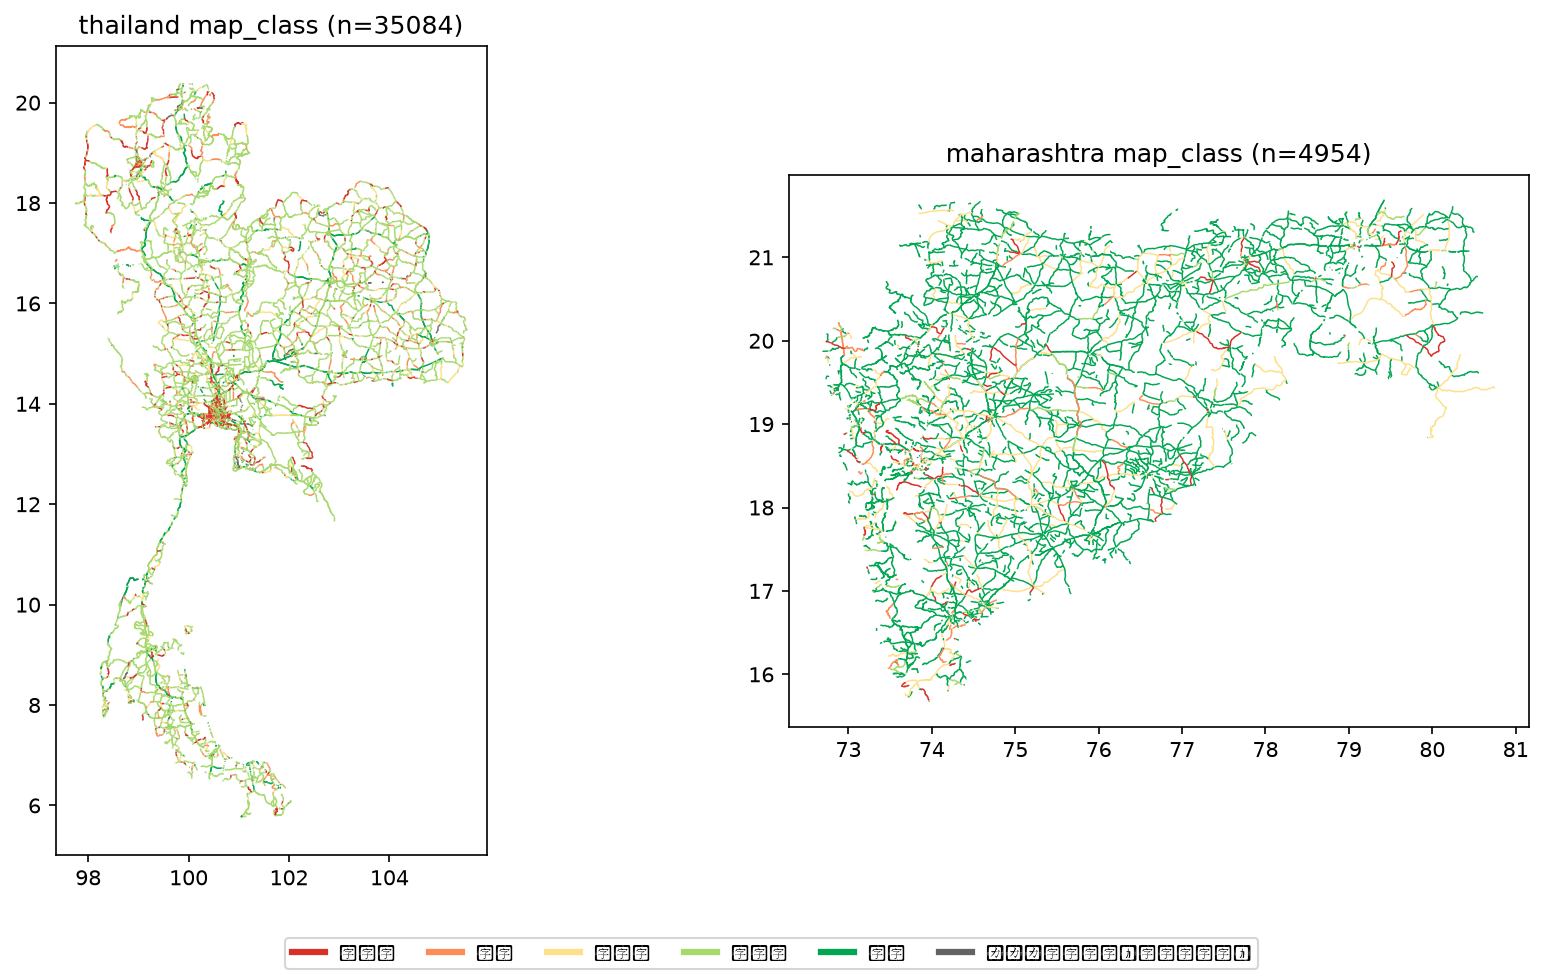


Open the following file in a browser to view the interactive map: outputs/priority_map.html


In [29]:
display(Image("outputs/priority_map_static.png"))
print
print("Open the following file in a browser to view the interactive map: outputs/priority_map.html")

---
# Sensitivity analysis (`sensitivity_analysis.py`)

Tests how much the Top Priority list depends on the choice of (1) the sample-density threshold and (2) the score-blending weights. (3) aggregates the Power Model exponent's 95% confidence interval, restricted to the benchmark target (segments in "Review Needed" with a positive reduction effect). All three simply reuse the columns of `target`, live-recomputed above (no writes to `outputs/` are involved).

In [30]:
from sensitivity_analysis import power_model_sensitivity, sample_size_robustness, weight_robustness

usable = target[target["data_quality_flag"].isna]

s = sample_size_robustness(usable)
print("1. Sample-size sensitivity: recompute the Top Priority list after excluding the bottom 25% (low sample)")
print(f" recall_of_baseline={s['recall_of_baseline']:.1%}, jaccard={s['jaccard']:.1%}")

1. Sample-size sensitivity: recompute the Top Priority list after excluding the bottom 25% (low sample)
 recall_of_baseline=84.4%, jaccard=84.4%


In [31]:
w = weight_robustness(usable)
print("2. Weight sensitivity: recompute the Top Priority list under 5 weighting settings including 0.50/0.35/0.15")
display(w[["n_baseline", "n_other", "n_overlap", "recall_of_baseline", "jaccard"]])

2. Weight sensitivity: recompute the Top Priority list under 5 weighting settings including 0.50/0.35/0.15


,n_baseline,n_other,n_overlap,recall_of_baseline,jaccard
scenario,,,,,
baseline (0.50/0.35/0.15),3130,3130,3130,1.000000,1.000000
equal weights (0.33/0.33/0.34),3130,3037,2876,0.918850,0.873899
misalignment-heavy (0.70/0.20/0.10),3130,1967,1757,0.561342,0.526048
exposure-heavy (0.30/0.55/0.15),3130,3216,3126,0.998722,0.970807
confidence-heavy (0.40/0.30/0.30),3130,2987,2891,0.923642,0.896156


In [32]:
p = power_model_sensitivity(usable)
print("3. Power Model exponent's 95% confidence interval (only segments in \"Review Needed\" with a positive reduction effect)")
display(p.round(1))

3. Power Model exponent's 95% confidence interval (only segments in "Review Needed" with a positive reduction effect)


,n,ci_low_mean,point_estimate_mean,ci_high_mean
power_environment_used,,,,
rural_freeway,4162,85.7,92.3,95.3
urban_residential,3073,16.1,75.0,90.6


---
# Phase 5 (optional) - Sprint extension: Mapillary integration

An extension based on `FINAL_SPRINT_PLAN.md`. Fetching Mapillary `map_features` (`fetch_mapillary_features.py`) requires an API token and has already been fetched and finalized as `data/mapillary/map_features_*.json`, as verified in Phase 1 (not re-fetched by this notebook). The fetched JSON is flattened and cached by Phase 2's `exposure_signals.add_poi_proximity` into `data/processed/mapillary_pois_*.parquet`, and computed into `is_mapillary_vru` (the OR of school-zone signs / crosswalk markings / bicycle markings, forced False for motorway/trunk/already-separated segments). V_safe's `pedestrian` classification is driven by `is_vru`, which ORs this `is_mapillary_vru` with the OSM school node; `is_mapillary_vru` itself is used in the urban exposure composite (the `poi_count` / `osm_poi_category_count` / `is_mapillary_vru` / `is_vru` columns actually computed in the Phase 2 cells above are that result).

See [`fetch_mapillary_features.ipynb`](fetch_mapillary_features.ipynb) for details of the fetch flow.

---
# Summary - mapping to the three deliverables

| Deliverable | How this notebook addresses it | Where it was verified |
|---|---|---|
| **Analytical model** | Across Phase 0-3, live-called each `src/` module, computed from V_safe (which never takes SpeedLimit as an argument) through to misalignment and score, verified an exact match against the committed intermediate artifact, and actually wrote out `outputs/` from that result | Phase 2, Phase 3, reproducibility check, Phase 4 |
| **Speed Safety Score** | A 0-100 score per segment + priority class + a plain-language explanation for non-technical readers (`score_explanation`) | Phase 3, `outputs/priority_*.csv` regenerated by this notebook |
| **Geospatial visualization** | Priority-segment map (interactive HTML + static PNG + GeoJSON/GPKG) | Phase 4, `outputs/priority_map.html` regenerated by this notebook |

**To verify the computation process further:**
- Full reproduction path (run the same logic as this notebook as a `.py` script): `python src/build_v_safe.py`
- Fast path (regenerate only the deliverables under `outputs/`): `python src/quick_reproduce.py`

**Known limitations** (see [`PIPELINE.md` ](../PIPELINE.md#10-known-limitations-assumptions-in-the-pipeline) for details): only segments with speed data are covered (~22% of the full road network); `LandUse`/`SpeedLimit` are themselves estimates in ADB's provided data; rural areas have thin OSM/Mapillary coverage, addressed with a safety-side correction.

See [`README.md`](../README.md) for detailed methodology, evaluation, and reproduction steps.